In [ ]:
# =============================================================================
# CELLULE 1 : IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [ ]:
# =============================================================================
# CELLULE 2 : CHARGEMENT DES DONNÉES
# =============================================================================

# Téléchargement (si nécessaire)
!kaggle datasets download -d atharvaingle/crop-recommendation-dataset
!unzip -o crop-recommendation-dataset.zip

# Chargement
df = pd.read_csv('Crop_recommendation.csv')
print(f"📊 Dataset chargé : {df.shape}")
display(df.head())

Dataset URL: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
License(s): apache-2.0
100% 63.7k/63.7k [00:00<00:00, 57.3MB/s]

Archive:  crop-recommendation-dataset.zip
  inflating: Crop_recommendation.csv  
📊 Dataset chargé : (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



📊 STATISTIQUES DESCRIPTIVES
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117 

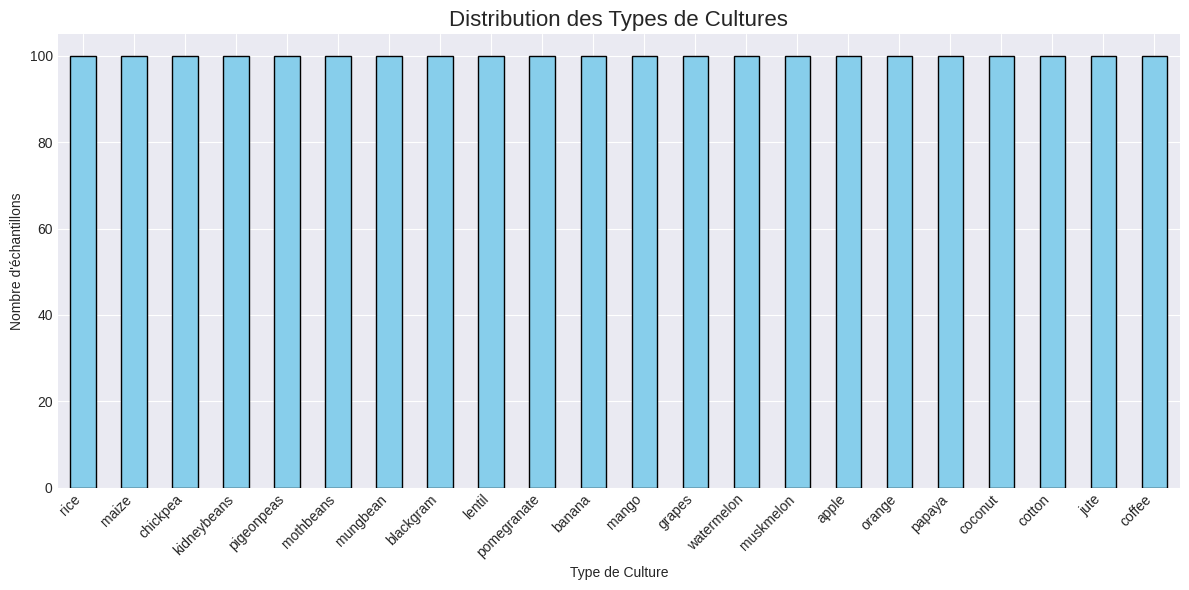

In [ ]:
# =============================================================================
# CELLULE 3 : ANALYSE EXPLORATOIRE
# =============================================================================

print("\n📊 STATISTIQUES DESCRIPTIVES")
print(df.describe())

print("\n🌾 DISTRIBUTION DES CULTURES")
print(df['label'].value_counts())

# Graphiques
plt.figure(figsize=(12, 6))
df['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution des Types de Cultures', fontsize=16)
plt.xlabel('Type de Culture')
plt.ylabel("Nombre d'échantillons")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CELLULE 4 : PRÉTRAITEMENT
# =============================================================================

# Séparation
X = df.drop('label', axis=1)
y = df['label']

# Encodage
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"✅ Train : {X_train.shape[0]} échantillons")
print(f"✅ Test : {X_test.shape[0]} échantillons")

# Sauvegarde
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("✅ Données sauvegardées")

✅ Train : 1760 échantillons
✅ Test : 440 échantillons
✅ Données sauvegardées


In [ ]:
# =============================================================================
# CELLULE 5 : ENTRAÎNEMENT DES MODÈLES
# =============================================================================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n▶️ Entraînement de {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    results[name] = {
        'Accuracy': accuracy,
        'F1-Score (macro)': f1_macro,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }

    print(f"   ✅ Accuracy: {accuracy:.4f}")
    print(f"   ✅ F1-Score: {f1_macro:.4f}")
    print(f"   ✅ CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


▶️ Entraînement de Logistic Regression...
   ✅ Accuracy: 0.9727
   ✅ F1-Score: 0.9725
   ✅ CV Score: 0.9676 (+/- 0.0113)

▶️ Entraînement de Decision Tree...
   ✅ Accuracy: 0.9795
   ✅ F1-Score: 0.9794
   ✅ CV Score: 0.9847 (+/- 0.0071)

▶️ Entraînement de Random Forest...
   ✅ Accuracy: 0.9955
   ✅ F1-Score: 0.9955
   ✅ CV Score: 0.9932 (+/- 0.0043)

▶️ Entraînement de XGBoost...
   ✅ Accuracy: 0.9909
   ✅ F1-Score: 0.9908
   ✅ CV Score: 0.9892 (+/- 0.0049)



📊 COMPARAISON DES MODÈLES
                     Accuracy  F1-Score (macro)  CV Mean  CV Std
Logistic Regression    0.9727            0.9725   0.9676  0.0113
Decision Tree          0.9795            0.9794   0.9847  0.0071
Random Forest          0.9955            0.9955   0.9932  0.0043
XGBoost                0.9909            0.9908   0.9892  0.0049

🏆 MEILLEUR MODÈLE : Random Forest
   Accuracy: 0.9955
✅ Modèle sauvegardé : best_model.pkl


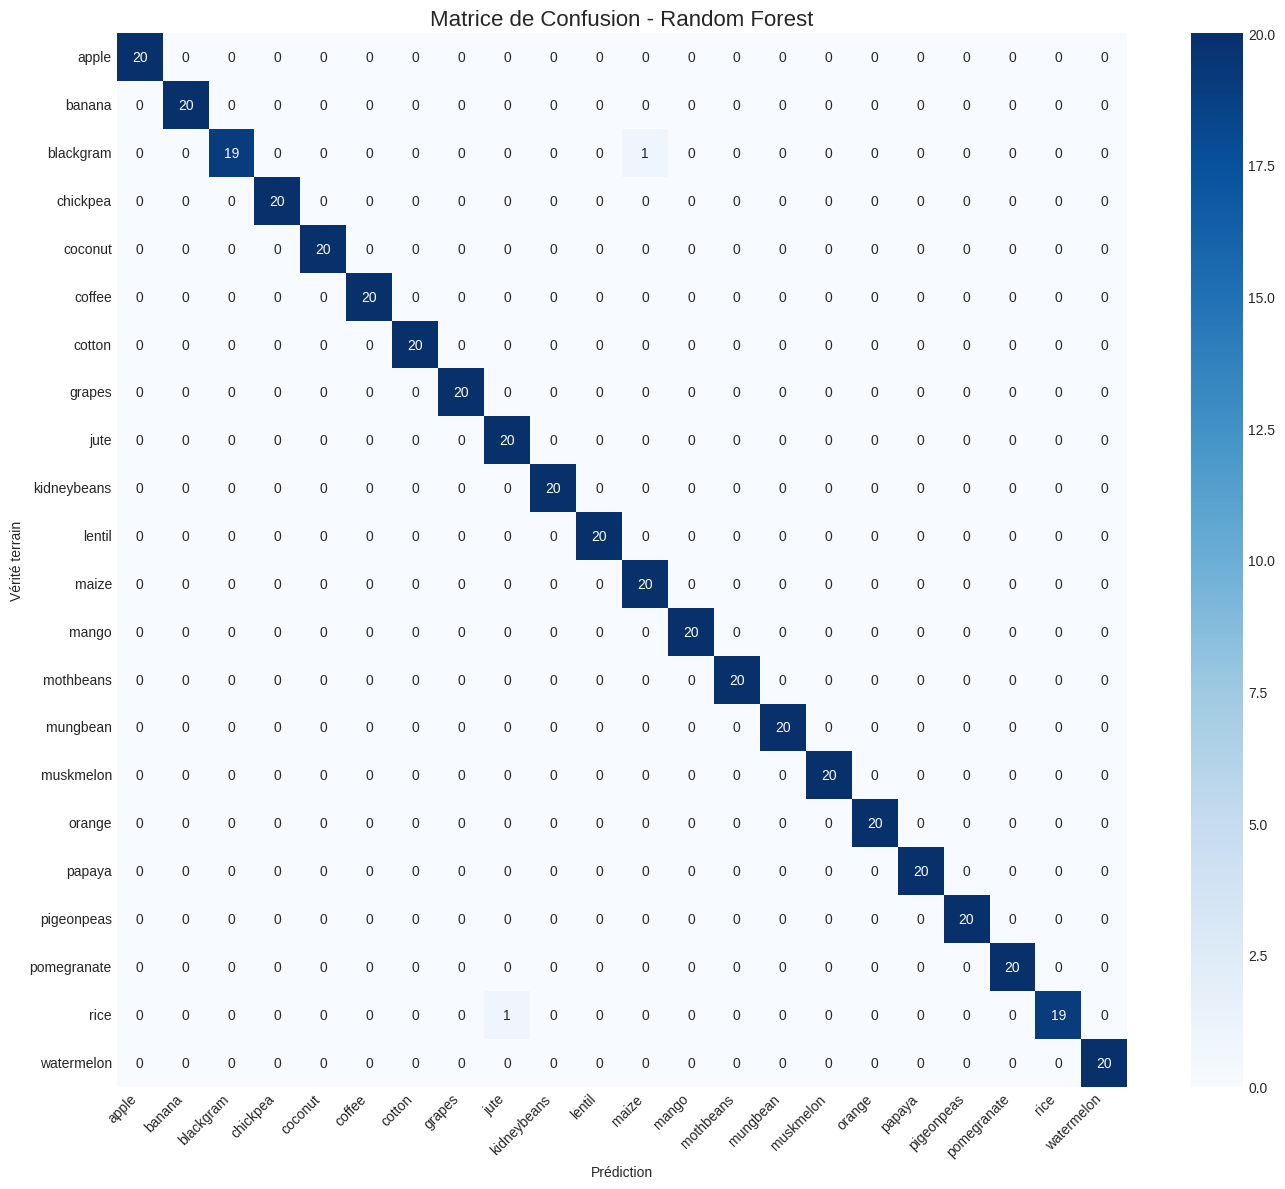

In [ ]:
# =============================================================================
# CELLULE 6 : COMPARAISON ET MEILLEUR MODÈLE
# =============================================================================

results_df = pd.DataFrame(results).T
print("\n📊 COMPARAISON DES MODÈLES")
print(results_df.round(4))

best_name = results_df['Accuracy'].idxmax()
best_model = models[best_name]
y_pred_best = predictions[best_name]

print(f"\n🏆 MEILLEUR MODÈLE : {best_name}")
print(f"   Accuracy: {results[best_name]['Accuracy']:.4f}")

# Sauvegarde
joblib.dump(best_model, 'best_model.pkl')
print(f"✅ Modèle sauvegardé : best_model.pkl")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Matrice de Confusion - {best_name}', fontsize=16)
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CELLULE 7 : INTERFACE GRADIO
# =============================================================================

import gradio as gr

def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    best_model = joblib.load('best_model.pkl')
    scaler = joblib.load('scaler.pkl')
    label_encoder = joblib.load('label_encoder.pkl')

    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    features_scaled = scaler.transform(features)

    prediction = best_model.predict(features_scaled)
    prediction_proba = best_model.predict_proba(features_scaled)

    crop_name = label_encoder.inverse_transform(prediction)[0]
    confidence = np.max(prediction_proba) * 100

    top_indices = np.argsort(prediction_proba[0])[-5:][::-1]
    top_crops = label_encoder.inverse_transform(top_indices)
    top_probs = prediction_proba[0][top_indices] * 100

    recommendations_df = pd.DataFrame({
        'Culture': top_crops,
        'Confiance (%)': top_probs.round(1)
    })

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(top_crops))]
    bars = ax.barh(top_crops, top_probs, color=colors, edgecolor='black')
    ax.set_xlabel('Probabilité (%)')
    ax.set_title('Top 5 Cultures Recommandées', fontsize=14)
    ax.set_xlim(0, 105)

    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{top_probs[i]:.1f}%',
                va='center', fontweight='bold')
    plt.tight_layout()

    return crop_name, f"Confiance: {confidence:.1f}%", recommendations_df, fig

# Création de l'interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🌾 AgriPredict - Système de Recommandation de Cultures
    """)

    with gr.Row():
        with gr.Column(scale=2):
            N = gr.Slider(0, 140, value=50, label="Azote (N) kg/ha")
            P = gr.Slider(0, 145, value=40, label="Phosphore (P) kg/ha")
            K = gr.Slider(0, 205, value=30, label="Potassium (K) kg/ha")
            temperature = gr.Slider(15, 35, value=20, label="Température (°C)")
            humidity = gr.Slider(40, 90, value=60, label="Humidité (%)")
            ph = gr.Slider(4.5, 8.5, value=6.5, step=0.1, label="pH du Sol")
            rainfall = gr.Slider(50, 300, value=100, label="Pluviométrie (mm)")
            predict_btn = gr.Button("🌾 Prédire la Culture", variant="primary", size="lg")

        with gr.Column(scale=1):
            crop_output = gr.Textbox(label="🌾 Culture Recommandée", interactive=False)
            confidence_output = gr.Textbox(label="🎯 Confiance du Modèle", interactive=False)

    with gr.Row():
        recommendations_table = gr.Dataframe(
            headers=["Culture", "Confiance (%)"],
            label="📋 Top 5 Cultures Recommandées",
            interactive=False
        )
        plot_output = gr.Plot(label="📈 Probabilités par Culture")

    predict_btn.click(
        predict_crop,
        inputs=[N, P, K, temperature, humidity, ph, rainfall],
        outputs=[crop_output, confidence_output, recommendations_table, plot_output]
    )

# Lancement
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e198af42ee6b6216a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
